In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Magnetic field of a finite straight wire above the plane

We simulate the magnetic field produced by a finite current-carrying wire using the **Biot–Savart law**.  
The wire is placed parallel to the \(x\)-axis, lifted by \(10\,\mu\text{m}\) above the \(xy\)-plane, and carries a current of \(2\,\text{mA}\).

## Geometry

- The observation region is a square in the \(xy\)-plane of side length \(200\,\mu\text{m}\).
- The grid spacing is \(5\,\mu\text{m}\).
- The wire lies at constant height \(z = 10\,\mu\text{m}\).
- The wire runs along the \(x\)-direction from the left side of the square to the right side.

Thus:
- \(x,y\) define the observation plane,
- \(z\) is the axis perpendicular to the plane.

## Law used: Biot–Savart law

For a small current element \(d\boldsymbol{\ell}\), the magnetic field contribution at an observation point is

\[
d\mathbf{B} = \frac{\mu_0 I}{4\pi}\frac{d\boldsymbol{\ell}\times\mathbf{r}}{|\mathbf{r}|^3}.
\]

The total magnetic field is obtained by summing all such contributions along the wire.

## Meaning of each parameter

- \(\mathbf{B}\): magnetic field vector at the observation point, in tesla.
- \(\mu_0\): vacuum permeability,  
  \[
  \mu_0 = 4\pi\times10^{-7}\,\text{T m/A},
  \]
  which sets the magnetic field scale in SI units.
- \(I\): current through the wire, here \(2\,\text{mA}\).
- \(d\boldsymbol{\ell}\): infinitesimal vector element of the wire, pointing in the direction of current flow.
- \(\mathbf{r}\): vector from the wire element to the observation point.
- \(|\mathbf{r}|\): distance from the wire element to the observation point.
- \(d\boldsymbol{\ell}\times\mathbf{r}\): cross product determining the direction of the magnetic field contribution.

## Numerical approximation

Because the wire is finite, we approximate it by dividing it into many short straight segments.  
For each segment, we evaluate the Biot–Savart contribution and sum them numerically over the full wire.

This is a **finite-wire approximation** to the continuous Biot–Savart integral.

## Physical interpretation

A current in the wire generates magnetic field lines that circulate around the wire according to the right-hand rule.  
Since the wire is elevated above the \(xy\)-plane, the field measured in the plane is asymmetric with respect to the wire height and contains both in-plane and out-of-plane components.

DEFINE Geometry


In [17]:
mu0 = 4 * np.pi * 1e-7   # vacuum permeability [T m / A]

# Current
I = 2e-3   # 2 mA

# Grid definition: 200 micrometers wide square, step 5 micrometers
L_um = 200
step_um = 5

x_um = np.arange(-L_um/2, L_um/2 + step_um, step_um)
y_um = np.arange(-L_um/2, L_um/2 + step_um, step_um)

x = x_um * 1e-6
y = y_um * 1e-6

X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)   # observation plane is z = 0

# Wire height above plane
z_wire = 10e-6   # 10 micrometers

# Finite straight wire across the square
r1 = np.array([0.0, -100e-6, z_wire])
r2 = np.array([0.0,  100e-6, z_wire])
# Discretize the wire into many short current elements
Nseg = 1000
t = np.linspace(0, 1, Nseg + 1)

wire_points = r1[None, :] + (r2 - r1)[None, :] * t[:, None]

# Midpoints of each segment
seg_mid = 0.5 * (wire_points[:-1] + wire_points[1:])

# Current element vectors dℓ
dl = wire_points[1:] - wire_points[:-1]

In [12]:
# Initialize magnetic field components on the grid
Bx = np.zeros_like(X, dtype=float)
By = np.zeros_like(X, dtype=float)
Bz = np.zeros_like(X, dtype=float)

# Biot-Savart law in discretized form:
# dB = mu0 / (4*pi) * I * (dℓ × r_vec) / |r_vec|^3

for i in range(Nseg):
    rx = X - seg_mid[i, 0]
    ry = Y - seg_mid[i, 1]
    rz = Z - seg_mid[i, 2]

    r_mag = np.sqrt(rx**2 + ry**2 + rz**2)

    # Avoid division problems extremely close to the wire
    r_mag = np.where(r_mag < 1e-15, 1e-15, r_mag)

    dlx, dly, dlz = dl[i]

    # Cross product dℓ × r
    cx = dly * rz - dlz * ry
    cy = dlz * rx - dlx * rz
    cz = dlx * ry - dly * rx

    prefactor = mu0 * I / (4 * np.pi * r_mag**3)

    Bx += prefactor * cx
    By += prefactor * cy
    Bz += prefactor * cz

In [13]:
Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

print("Grid shape:", X.shape)
print("Max |B| [T]:", np.max(Bmag))
print("Max |B| [uT]:", np.max(Bmag) * 1e6)

Grid shape: (41, 41)
Max |B| [T]: 3.9801487803485424e-05
Max |B| [uT]: 39.80148780348542


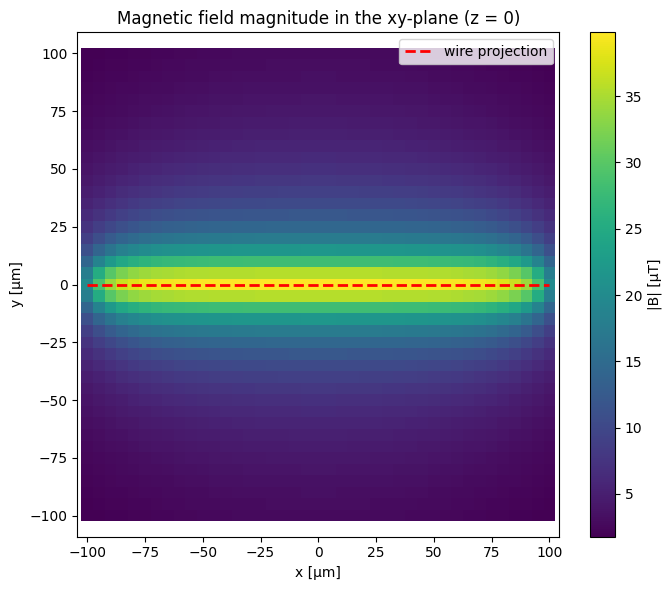

In [14]:
plt.figure(figsize=(7, 6))
plt.pcolormesh(X * 1e6, Y * 1e6, Bmag * 1e6, shading='auto')
plt.colorbar(label='|B| [µT]')
plt.xlabel('x [µm]')
plt.ylabel('y [µm]')
plt.title('Magnetic field magnitude in the xy-plane (z = 0)')

# Plot wire projection onto xy plane
plt.plot([r1[0]*1e6, r2[0]*1e6], [r1[1]*1e6, r2[1]*1e6], 'r--', lw=2, label='wire projection')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

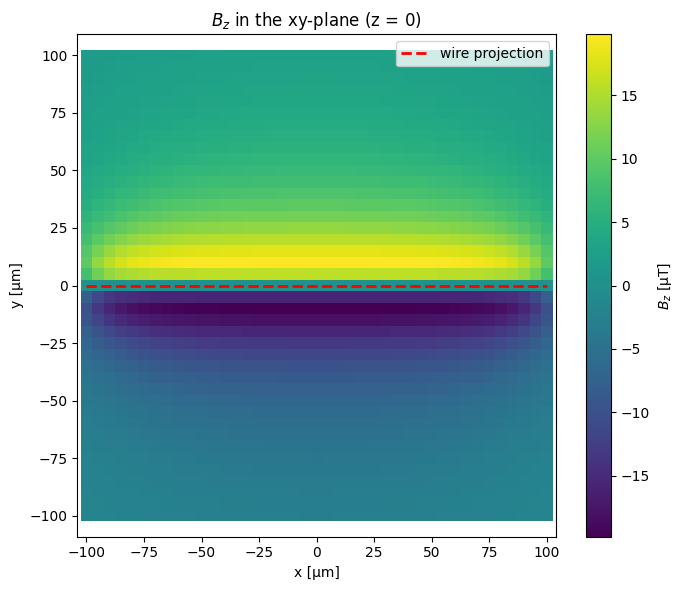

In [15]:
plt.figure(figsize=(7, 6))
plt.pcolormesh(X * 1e6, Y * 1e6, Bz * 1e6, shading='auto')
plt.colorbar(label='$B_z$ [µT]')
plt.xlabel('x [µm]')
plt.ylabel('y [µm]')
plt.title('$B_z$ in the xy-plane (z = 0)')

plt.plot([r1[0]*1e6, r2[0]*1e6], [r1[1]*1e6, r2[1]*1e6], 'r--', lw=2, label='wire projection')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

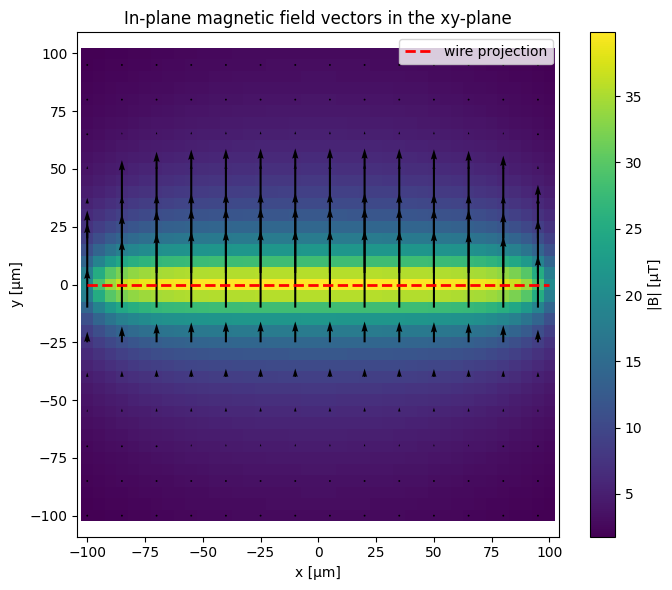

In [16]:
# Downsample for quiver visibility
skip = 3

plt.figure(figsize=(7, 6))
plt.pcolormesh(X * 1e6, Y * 1e6, Bmag * 1e6, shading='auto')
plt.colorbar(label='|B| [µT]')

plt.quiver(
    X[::skip, ::skip] * 1e6,
    Y[::skip, ::skip] * 1e6,
    Bx[::skip, ::skip],
    By[::skip, ::skip],
    scale=None
)

plt.plot([r1[0]*1e6, r2[0]*1e6], [r1[1]*1e6, r2[1]*1e6], 'r--', lw=2, label='wire projection')
plt.xlabel('x [µm]')
plt.ylabel('y [µm]')
plt.title('In-plane magnetic field vectors in the xy-plane')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

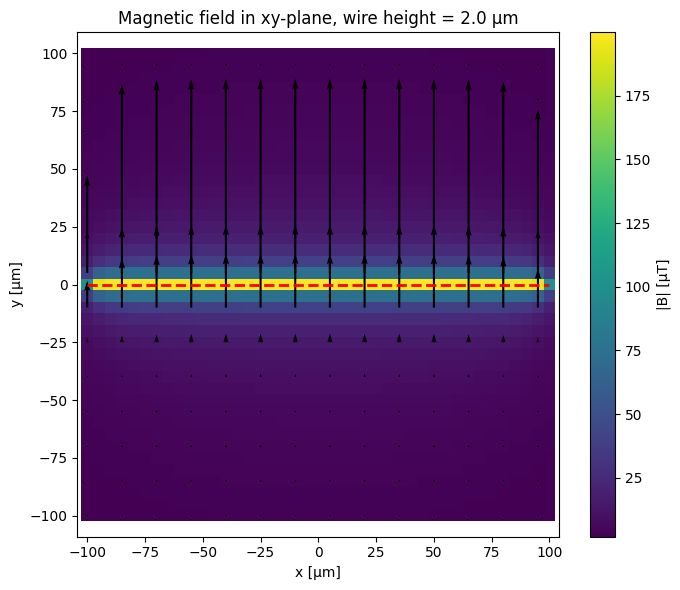

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Reuse grid and constants
mu0 = 4 * np.pi * 1e-7
I = 2e-3

L_um = 200
step_um = 5

x_um = np.arange(-L_um/2, L_um/2 + step_um, step_um)
y_um = np.arange(-L_um/2, L_um/2 + step_um, step_um)

x = x_um * 1e-6
y = y_um * 1e-6
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

# Wire geometry
y_wire = 0.0
x1 = -100e-6
x2 =  100e-6

Nseg = 500

# Heights to animate
z_vals_um = np.linspace(2, 30, 40)
z_vals = z_vals_um * 1e-6

# Precompute fields for all frames
Bmag_frames = []
Bx_frames = []
By_frames = []

for z_wire in z_vals:
    r1 = np.array([x1, y_wire, z_wire])
    r2 = np.array([x2, y_wire, z_wire])

    t = np.linspace(0, 1, Nseg + 1)
    wire_points = r1[None, :] + (r2 - r1)[None, :] * t[:, None]
    seg_mid = 0.5 * (wire_points[:-1] + wire_points[1:])
    dl = wire_points[1:] - wire_points[:-1]

    Bx = np.zeros_like(X, dtype=float)
    By = np.zeros_like(X, dtype=float)
    Bz = np.zeros_like(X, dtype=float)

    for i in range(Nseg):
        rx = X - seg_mid[i, 0]
        ry = Y - seg_mid[i, 1]
        rz = Z - seg_mid[i, 2]

        r_mag = np.sqrt(rx**2 + ry**2 + rz**2)
        r_mag = np.where(r_mag < 1e-15, 1e-15, r_mag)

        dlx, dly, dlz = dl[i]

        cx = dly * rz - dlz * ry
        cy = dlz * rx - dlx * rz
        cz = dlx * ry - dly * rx

        prefactor = mu0 * I / (4 * np.pi * r_mag**3)

        Bx += prefactor * cx
        By += prefactor * cy
        Bz += prefactor * cz

    Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

    Bmag_frames.append(Bmag.copy())
    Bx_frames.append(Bx.copy())
    By_frames.append(By.copy())

# Plot setup
fig, ax = plt.subplots(figsize=(7, 6))

pcm = ax.pcolormesh(X * 1e6, Y * 1e6, Bmag_frames[0] * 1e6, shading='auto')
cbar = plt.colorbar(pcm, ax=ax, label='|B| [µT]')

skip = 3
quiv = ax.quiver(
    X[::skip, ::skip] * 1e6,
    Y[::skip, ::skip] * 1e6,
    Bx_frames[0][::skip, ::skip],
    By_frames[0][::skip, ::skip]
)

wire_line, = ax.plot([x1*1e6, x2*1e6], [y_wire*1e6, y_wire*1e6], 'r--', lw=2)

title = ax.set_title(f'Magnetic field in xy-plane, wire height = {z_vals_um[0]:.1f} µm')
ax.set_xlabel('x [µm]')
ax.set_ylabel('y [µm]')
ax.axis('equal')

def update(frame):
    pcm.set_array((Bmag_frames[frame] * 1e6).ravel())
    quiv.set_UVC(
        Bx_frames[frame][::skip, ::skip],
        By_frames[frame][::skip, ::skip]
    )
    title.set_text(f'Magnetic field in xy-plane, wire height = {z_vals_um[frame]:.1f} µm')
    return pcm, quiv, title

anim = FuncAnimation(fig, update, frames=len(z_vals), interval=150, blit=False)

plt.tight_layout()
HTML(anim.to_jshtml())